# S16 – CLIP: общие embedding-пространства для текста и изображений

В этом ноутбуке делаем следующий логичный шаг после **LLM** и **RAG**:  
переходим к **мультимодальным моделям**, которые умеют работать сразу с несколькими типами данных.

Начнём с одного из самых важных и понятных примеров – **CLIP**.  
Эта модель переводит **текст** и **изображения** в **общее пространство признаков**,  
где можно измерять их семантическую близость.

Главная цель ноутбука – показать несколько уровней практической работы с CLIP:

- получаем `image embeddings` и `text embeddings`;
- считаем сходство текста и изображения;
- делаем **zero-shot matching** без дообучения;
- смотрим, как на результат влияет формулировка текстового описания;
- используем CLIP как простейший **zero-shot классификатор изображений**.

Важно: мы сознательно используем **готовую модель** и **небольшой учебный набор картинок**,  
чтобы сфокусироваться на самой инженерной идее мультимодальности, а не на тяжёлой инфраструктуре.

В качестве визуальных данных возьмём компактную выборку из **CIFAR-10**.  
Это не «боевой» датасет, а удобный учебный материал: на нём легко увидеть,  
как работает общее embedding-пространство и где у zero-shot подхода возникают ограничения.


## 0. План

К концу ноутбука надо уметь:

1. Загружать готовую CLIP-модель и процессор.
2. Подготавливать небольшой набор изображений для мультимодального анализа.
3. Получать `image embeddings` и `text embeddings`.
4. Считать матрицу сходства между картинками и текстовыми описаниями.
5. Сравнивать несколько prompt-шаблонов для одного и того же класса.
6. Выполнять zero-shot классификацию изображений через список текстовых классов.
7. Делать батчевый прогон и собирать сводную таблицу результатов.
8. Видеть ограничения CLIP и понимать, когда нужен более специальный мультимодальный пайплайн.


## 1. Импорты и общие настройки

Ниже подключаем библиотеки, фиксируем `seed`, выбираем устройство и загружаем готовую CLIP-модель.

> Предполагается, что в окружении уже доступны `torch`, `transformers`, `torchvision`, `pillow`, `matplotlib`, `pandas` и `numpy`.
> Если `torchvision` отсутствует, его нужно установить отдельно.


In [1]:

# Базовые библиотеки для воспроизводимости, работы с изображениями и CLIP.
import os
import random
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from PIL import Image
from torchvision.datasets import CIFAR10
from transformers import CLIPModel, CLIPProcessor

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 220)
pd.set_option("display.precision", 4)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch: 2.10.0+cu128
CUDA available: True


In [2]:

# Фиксируем seed, определяем устройство и загружаем CLIP.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)

MODEL_NAME = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
clip_model.eval()

print("Загружена модель:", MODEL_NAME)


Устройство: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Загружена модель: openai/clip-vit-base-patch32


## 2. Учебный набор изображений и постановка задачи

Возьмём небольшой поднабор изображений из **CIFAR-10**.  
Этот датасет удобен для учебной демонстрации:

- классы заранее известны;
- картинки компактные;
- можно быстро собрать маленькую локальную выборку;
- легко проверить, какие классы CLIP различает хорошо, а где начинаются ошибки.

Для первого знакомства возьмём несколько классов:

- `airplane`
- `automobile`
- `bird`
- `cat`
- `dog`
- `horse`
- `ship`
- `truck`

Ниже соберём по несколько изображений каждого класса и посмотрим на них как на мини-галерею.


In [3]:

CIFAR_ROOT = Path("data")
cifar_test = CIFAR10(root=CIFAR_ROOT, train=False, download=True)

all_classes = cifar_test.classes
selected_classes = ["airplane", "automobile", "bird", "cat", "dog", "horse", "ship", "truck"]
target_per_class = 3

records: List[Dict[str, object]] = []
class_counts = {cls: 0 for cls in selected_classes}

for image, label_id in cifar_test:
    class_name = all_classes[label_id]
    if class_name not in selected_classes:
        continue
    if class_counts[class_name] >= target_per_class:
        continue

    records.append(
        {
            "class_name": class_name,
            "label_id": label_id,
            "image": image,
            "image_id": f"{class_name}_{class_counts[class_name]:02d}",
        }
    )
    class_counts[class_name] += 1

    if all(count >= target_per_class for count in class_counts.values()):
        break

demo_df = pd.DataFrame(records)
demo_df[["image_id", "class_name"]].head(10)


100%|██████████| 170M/170M [00:07<00:00, 21.4MB/s]


,image_id,class_name
0,cat_00,cat
1,ship_00,ship
2,ship_01,ship
3,airplane_00,airplane
4,automobile_00,automobile
5,cat_01,cat
6,automobile_01,automobile
7,airplane_01,airplane
8,truck_00,truck
9,dog_00,dog


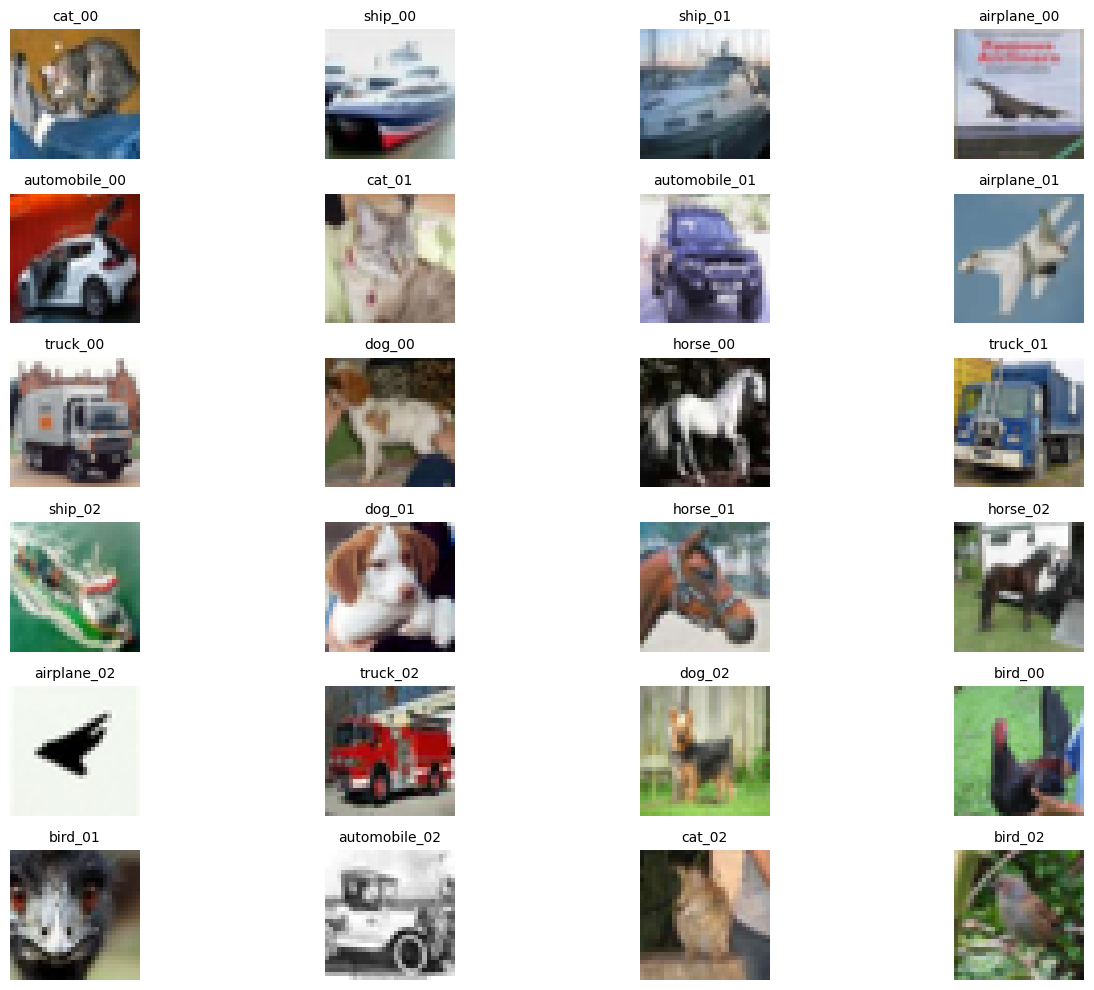

In [4]:

# Визуализируем учебную галерею.
def plot_image_grid(images: List[Image.Image], titles: List[str], cols: int = 4, figsize: Tuple[int, int] = (14, 8)) -> None:
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for idx, (img, title) in enumerate(zip(images, titles), start=1):
        ax = plt.subplot(rows, cols, idx)
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_image_grid(
    images=demo_df["image"].tolist(),
    titles=demo_df["image_id"].tolist(),
    cols=4,
    figsize=(14, 10),
)


## 3. Как CLIP переводит текст и изображение в общее пространство признаков

У CLIP есть два симметричных представления:

- одно для **изображения**;
- другое для **текста**.

Оба типа входов переводятся в векторы одной и той же размерности.  
После этого можно:

- нормализовать векторы;
- посчитать **cosine similarity**;
- сравнивать, какой текст ближе к какому изображению.

Ниже напишем служебные функции для получения embedding-векторов.


In [5]:

def l2_normalize(tensor: torch.Tensor) -> torch.Tensor:
    return tensor / tensor.norm(dim=-1, keepdim=True)


def encode_images(images: List[Image.Image]) -> torch.Tensor:
    inputs = processor(images=images, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        # В transformers 5.x get_image_features возвращает BaseModelOutputWithPooling;
        # спроецированные признаки (после visual_projection) лежат в .pooler_output.
        image_features = clip_model.get_image_features(**inputs).pooler_output

    return l2_normalize(image_features).cpu()


def encode_texts(texts: List[str]) -> torch.Tensor:
    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        # Аналогично для текста: text_projection уже применён, результат в .pooler_output.
        text_features = clip_model.get_text_features(**inputs).pooler_output

    return l2_normalize(text_features).cpu()


image_embeddings = encode_images(demo_df["image"].tolist())
print("Размерность image embeddings:", tuple(image_embeddings.shape))


Размерность image embeddings: (24, 512)


In [6]:

candidate_texts = [
    "a photo of an airplane",
    "a photo of a car",
    "a photo of a bird",
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a horse",
    "a photo of a ship",
    "a photo of a truck",
]

text_embeddings = encode_texts(candidate_texts)

# После L2-нормализации скалярное произведение совпадает с косинусным сходством:
# cos(a, b) = (a · b) / (|a| · |b|) = a · b, когда |a| = |b| = 1.
similarity_matrix = image_embeddings @ text_embeddings.T

similarity_df = pd.DataFrame(
    similarity_matrix.numpy(),
    index=demo_df["image_id"],
    columns=candidate_texts,
)
similarity_df.head(8)


,a photo of an airplane,a photo of a car,a photo of a bird,a photo of a cat,a photo of a dog,a photo of a horse,a photo of a ship,a photo of a truck
image_id,,,,,,,,
cat_00,0.1824,0.1859,0.1997,0.2143,0.2076,0.1901,0.2005,0.1750
ship_00,0.1983,0.2032,0.1904,0.1857,0.1835,0.1813,0.2623,0.1932
ship_01,0.1997,0.2217,0.1940,0.1968,0.1936,0.1840,0.2352,0.2051
airplane_00,0.2391,0.1985,0.2351,0.1912,0.1890,0.2027,0.2046,0.1917
automobile_00,0.1872,0.2610,0.1915,0.1892,0.1947,0.1856,0.1988,0.2059
cat_01,0.1821,0.1920,0.2042,0.2602,0.2263,0.2054,0.1900,0.1853
automobile_01,0.1737,0.2359,0.1905,0.1921,0.1985,0.1884,0.1750,0.2328
airplane_01,0.2607,0.2010,0.2342,0.2067,0.2125,0.2034,0.2141,0.1903


## 4. Первый zero-shot image-text matching

Теперь у нас есть:

- embeddings изображений;
- embeddings текстовых описаний;
- матрица сходства между ними.

Посмотрим на неё как на heatmap и проверим, совпадает ли интуитивно максимум по строке  
с ожидаемым классом изображения.


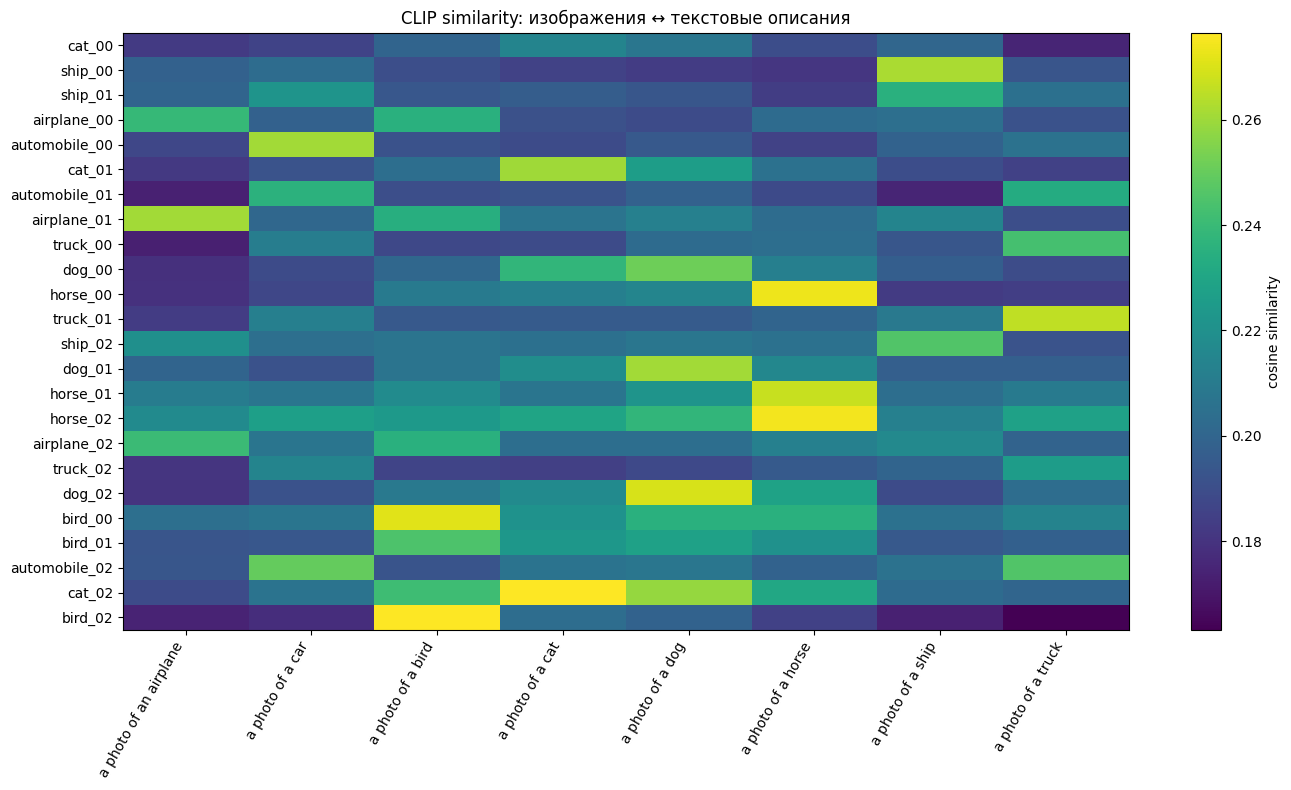

In [7]:

plt.figure(figsize=(14, 8))
plt.imshow(similarity_df.values, aspect="auto")
plt.xticks(range(len(similarity_df.columns)), similarity_df.columns, rotation=60, ha="right")
plt.yticks(range(len(similarity_df.index)), similarity_df.index)
plt.colorbar(label="cosine similarity")
plt.title("CLIP similarity: изображения ↔ текстовые описания")
plt.tight_layout()
plt.show()


In [8]:

prompt_to_class = {
    "a photo of an airplane": "airplane",
    "a photo of a car": "automobile",
    "a photo of a bird": "bird",
    "a photo of a cat": "cat",
    "a photo of a dog": "dog",
    "a photo of a horse": "horse",
    "a photo of a ship": "ship",
    "a photo of a truck": "truck",
}

top_prompt_idx = similarity_matrix.argmax(dim=1).numpy()
demo_df["pred_prompt"] = [candidate_texts[idx] for idx in top_prompt_idx]
demo_df["pred_class"] = demo_df["pred_prompt"].map(prompt_to_class)
demo_df["is_correct"] = demo_df["pred_class"] == demo_df["class_name"]
demo_df[["image_id", "class_name", "pred_class", "is_correct"]]


,image_id,class_name,pred_class,is_correct
0,cat_00,cat,cat,True
1,ship_00,ship,ship,True
2,ship_01,ship,ship,True
3,airplane_00,airplane,airplane,True
4,automobile_00,automobile,automobile,True
5,cat_01,cat,cat,True
6,automobile_01,automobile,automobile,True
7,airplane_01,airplane,airplane,True
8,truck_00,truck,truck,True
9,dog_00,dog,dog,True


## 5. Как меняется результат при изменении текстового описания

Как и в случае с prompt engineering для LLM,  
формулировка текста для CLIP тоже имеет значение.

Возьмём одну и ту же семантику – например, класс `cat` –  
и посмотрим, как модель оценивает шесть текстовых вариантов:

- `"cat"` – голое ключевое слово;
- `"a photo of a cat"` – стандартный CLIP-шаблон;
- `"a small cat"` – атрибутивное уточнение;
- `"a domestic cat"` – категориальное уточнение;
- `"an animal"` – слишком общее, но в правильной категории;
- `"a vehicle"` – заведомо нерелевантный класс.

Это хороший способ почувствовать, что zero-shot мультимодальность тоже зависит от качества текстового запроса.


In [9]:

cat_example = demo_df[demo_df["class_name"] == "cat"].iloc[0]["image"]

cat_prompt_variants = [
    "cat",
    "a photo of a cat",
    "a small cat",
    "a domestic cat",
    "an animal",
    "a vehicle",
]

cat_image_embedding = encode_images([cat_example])
cat_text_embeddings = encode_texts(cat_prompt_variants)
cat_scores = (cat_image_embedding @ cat_text_embeddings.T).flatten().numpy()

prompt_effect_df = pd.DataFrame(
    {
        "prompt_variant": cat_prompt_variants,
        "similarity": cat_scores,
    }
).sort_values("similarity", ascending=False)

prompt_effect_df


,prompt_variant,similarity
3,a domestic cat,0.2250
1,a photo of a cat,0.2143
0,cat,0.2081
2,a small cat,0.2081
4,an animal,0.2038
5,a vehicle,0.1905


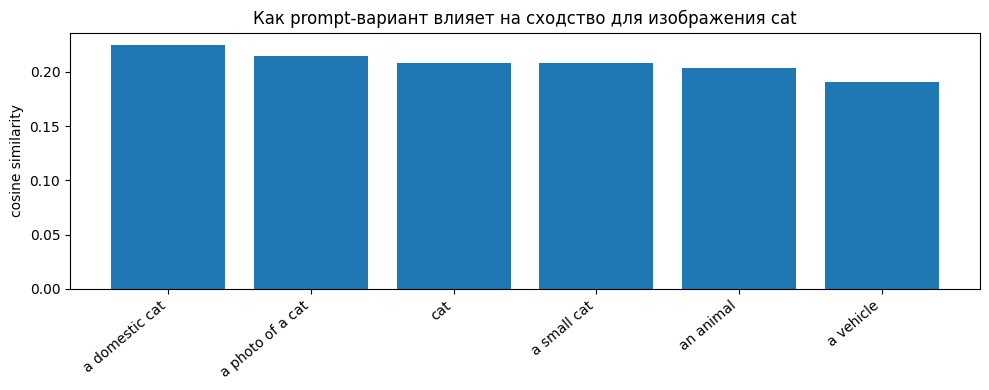

In [10]:

plt.figure(figsize=(10, 4))
plt.bar(prompt_effect_df["prompt_variant"], prompt_effect_df["similarity"])
plt.xticks(rotation=40, ha="right")
plt.ylabel("cosine similarity")
plt.title("Как prompt-вариант влияет на сходство для изображения cat")
plt.tight_layout()
plt.show()


## 6. Zero-shot классификация изображения через список текстовых классов

Теперь сделаем следующий шаг:  
будем использовать CLIP как **zero-shot классификатор**.

Идея простая:

1. задаём список классов в виде текстовых описаний;
2. считаем similarity между изображением и каждым текстом;
3. выбираем класс с максимальным score.

Ниже возьмём уже более широкий поднабор CIFAR-10 и оценим,
насколько такой подход работает на небольшом батче изображений.


In [11]:

# Собираем более широкий eval-набор: по 8 изображений на класс из всех 10 классов CIFAR-10.
eval_target_per_class = 8
eval_records: List[Dict[str, object]] = []
eval_counts = {cls: 0 for cls in all_classes}

for image, label_id in cifar_test:
    class_name = all_classes[label_id]
    if eval_counts[class_name] >= eval_target_per_class:
        continue

    eval_records.append(
        {
            "class_name": class_name,
            "image": image,
            "image_id": f"{class_name}_{eval_counts[class_name]:02d}",
        }
    )
    eval_counts[class_name] += 1

    if all(count >= eval_target_per_class for count in eval_counts.values()):
        break

eval_df = pd.DataFrame(eval_records)
eval_df.shape


(80, 3)

In [12]:

# Для zero-shot классификации стараемся использовать чуть более естественные формулировки классов.
zero_shot_class_prompts = {
    "airplane": "a photo of an airplane",
    "automobile": "a photo of a car",
    "bird": "a photo of a bird",
    "cat": "a photo of a cat",
    "deer": "a photo of a deer",
    "dog": "a photo of a dog",
    "frog": "a photo of a frog",
    "horse": "a photo of a horse",
    "ship": "a photo of a ship",
    "truck": "a photo of a truck",
}

class_names = list(zero_shot_class_prompts.keys())
class_prompt_texts = list(zero_shot_class_prompts.values())

eval_image_embeddings = encode_images(eval_df["image"].tolist())
eval_text_embeddings = encode_texts(class_prompt_texts)
eval_similarity = eval_image_embeddings @ eval_text_embeddings.T

top_class_idx = eval_similarity.argmax(dim=1).numpy()
eval_df["pred_class"] = [class_names[idx] for idx in top_class_idx]
eval_df["score"] = eval_similarity.max(dim=1).values.numpy()
eval_df["is_correct"] = eval_df["pred_class"] == eval_df["class_name"]

accuracy = eval_df["is_correct"].mean()
print(f"Zero-shot accuracy on small CIFAR subset: {accuracy:.3f}")

eval_df[["image_id", "class_name", "pred_class", "score", "is_correct"]].head(12)


Zero-shot accuracy on small CIFAR subset: 0.900


,image_id,class_name,pred_class,score,is_correct
0,cat_00,cat,cat,0.2143,True
1,ship_00,ship,ship,0.2623,True
2,ship_01,ship,ship,0.2352,True
3,airplane_00,airplane,airplane,0.2391,True
4,frog_00,frog,frog,0.2906,True
5,frog_01,frog,cat,0.2601,False
6,automobile_00,automobile,automobile,0.2610,True
7,frog_02,frog,frog,0.2577,True
8,cat_01,cat,cat,0.2602,True
9,automobile_01,automobile,automobile,0.2359,True


In [13]:

# Сводим результаты по классам.
class_summary_df = (
    eval_df.groupby("class_name", as_index=False)
    .agg(
        n=("image_id", "count"),
        accuracy=("is_correct", "mean"),
        avg_score=("score", "mean"),
    )
    .sort_values("accuracy", ascending=False)
)

class_summary_df


,class_name,n,accuracy,avg_score
1,automobile,8,1.000,0.2563
3,cat,8,1.000,0.2503
8,ship,8,1.000,0.2537
7,horse,8,1.000,0.2732
0,airplane,8,0.875,0.2524
2,bird,8,0.875,0.2630
6,frog,8,0.875,0.2622
9,truck,8,0.875,0.2474
5,dog,8,0.750,0.2569
4,deer,8,0.750,0.2701


## 7. Батчевый прогон и сводная таблица результатов

Соберём для каждого изображения не только лучший класс,  
но и **top-3 текстовых кандидата**.

Такой формат ближе к реальной инженерной задаче:  
нам полезно видеть не только итоговый ответ, но и альтернативы модели.


In [14]:

top_k = 3
top_values, top_indices = torch.topk(eval_similarity, k=top_k, dim=1)

topk_records: List[Dict[str, object]] = []
for row_idx, row in eval_df.reset_index(drop=True).iterrows():
    for rank in range(top_k):
        class_idx = int(top_indices[row_idx, rank].item())
        topk_records.append(
            {
                "image_id": row["image_id"],
                "true_class": row["class_name"],
                "rank": rank + 1,
                "candidate_class": class_names[class_idx],
                "candidate_prompt": class_prompt_texts[class_idx],
                "score": float(top_values[row_idx, rank].item()),
            }
        )

topk_df = pd.DataFrame(topk_records)
topk_df.head(12)


,image_id,true_class,rank,candidate_class,candidate_prompt,score
0,cat_00,cat,1,cat,a photo of a cat,0.2143
1,cat_00,cat,2,dog,a photo of a dog,0.2076
2,cat_00,cat,3,ship,a photo of a ship,0.2005
3,ship_00,ship,1,ship,a photo of a ship,0.2623
4,ship_00,ship,2,automobile,a photo of a car,0.2032
5,ship_00,ship,3,airplane,a photo of an airplane,0.1983
6,ship_01,ship,1,ship,a photo of a ship,0.2352
7,ship_01,ship,2,automobile,a photo of a car,0.2217
8,ship_01,ship,3,truck,a photo of a truck,0.2051
9,airplane_00,airplane,1,airplane,a photo of an airplane,0.2391


## 8. Где CLIP ошибается

Даже на небольшом учебном наборе видно, что zero-shot подход не идеален.  
Полезно явно посмотреть на ошибки и понять, где именно модель путается.

Частые причины:

- визуально близкие классы;
- маленький размер изображения;
- слишком грубые или слишком общие текстовые описания;
- доменный разрыв между обучением CLIP и конкретным набором данных.


In [15]:

error_df = eval_df[~eval_df["is_correct"]].copy()
error_df = error_df.merge(
    topk_df[topk_df["rank"] == 1][["image_id", "candidate_prompt"]],
    on="image_id",
    how="left",
)

print("Количество ошибок:", len(error_df))
error_df[["image_id", "class_name", "pred_class", "score", "candidate_prompt"]].head(15)


Количество ошибок: 8


,image_id,class_name,pred_class,score,candidate_prompt
0,frog_01,frog,cat,0.2601,a photo of a cat
1,deer_04,deer,horse,0.2386,a photo of a horse
2,dog_06,dog,bird,0.2248,a photo of a bird
3,truck_07,truck,ship,0.2263,a photo of a ship
4,deer_05,deer,dog,0.2482,a photo of a dog
5,airplane_06,airplane,truck,0.2372,a photo of a truck
6,bird_06,bird,horse,0.2422,a photo of a horse
7,dog_07,dog,horse,0.2402,a photo of a horse


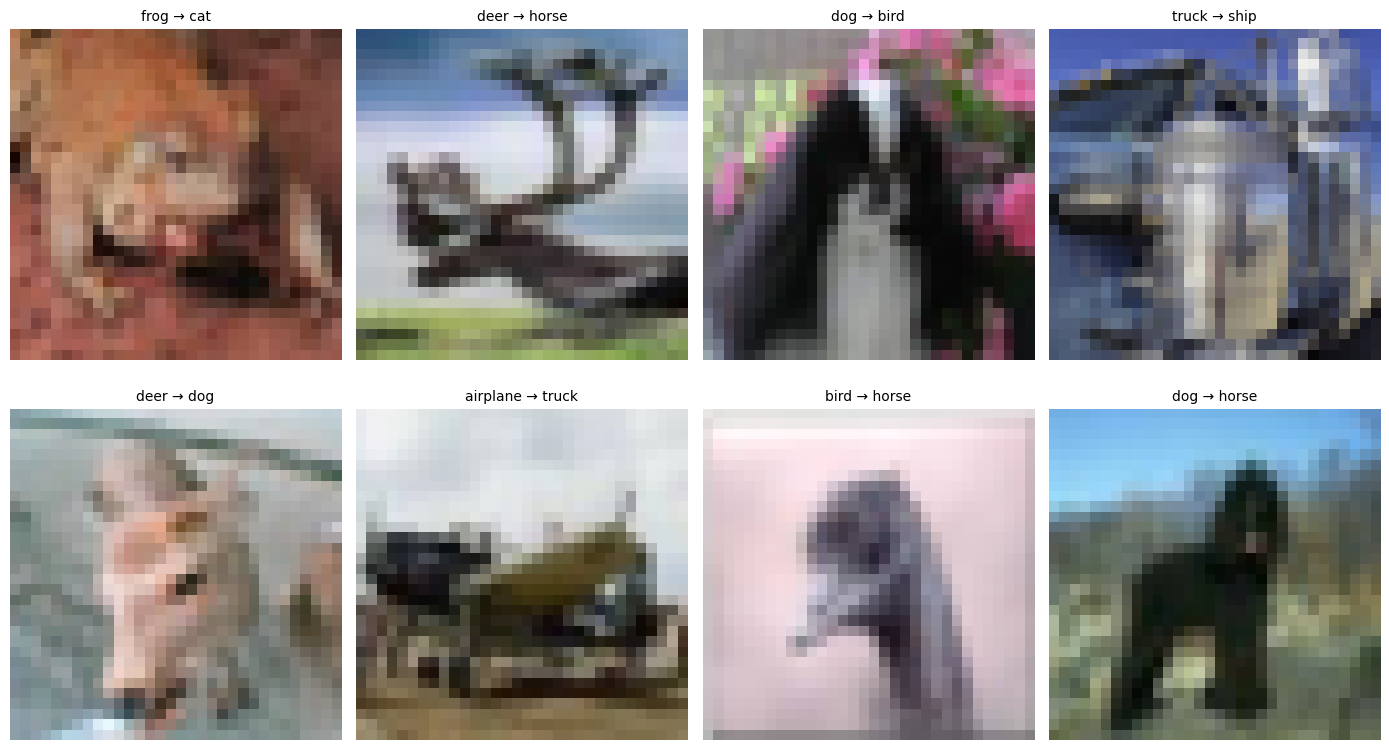

In [16]:

# Покажем несколько ошибок визуально.
error_sample = error_df.head(8)
if len(error_sample) > 0:
    plot_image_grid(
        images=error_sample["image"].tolist(),
        titles=[
            f"{row.class_name} → {row.pred_class}"
            for row in error_sample.itertuples()
        ],
        cols=4,
        figsize=(14, 8),
    )
else:
    print("На текущем поднаборе ошибок не оказалось – можно увеличить размер eval-набора.")


## 9. Ограничения zero-shot мультимодального подхода

На этом этапе важно сделать правильный инженерный вывод.

CLIP хорошо работает, когда:

- классы или запросы семантически различимы;
- домен близок к тому, на чём модель видела данные при обучении;
- нам нужен быстрый baseline без дообучения;
- полезно получить не «жёсткую» метку, а ранжирование по близости.

Но CLIP не является универсальным решением:

- на узкоспециализированных доменах может понадобиться адаптация;
- сходство сильно зависит от формулировки текста;
- мелкие детали, редкие объекты и тонкие различия модель может терять;
- similarity score сам по себе не гарантирует калиброванную вероятность.

То есть CLIP – это очень сильный **первый мультимодальный baseline**,  
но не автоматическая замена полноценному доменному пайплайну.


## 10. Итоги

В этом ноутбуке мы:

- загрузили готовую CLIP-модель;
- получили embeddings для изображений и текста;
- построили матрицу сходства;
- посмотрели, как работает zero-shot matching;
- увидели влияние текстовой формулировки;
- использовали CLIP как zero-shot классификатор;
- разобрали типичные ошибки и ограничения.

Это базовая, но очень важная инженерная точка входа в мультимодальные модели:  
**текст и изображение можно переводить в общее пространство признаков и сравнивать напрямую**.


## Задания для самостоятельной работы

1. Замените часть prompt-шаблонов и сравните, как меняется zero-shot качество.
2. Возьмите другой поднабор CIFAR-10 или собственный набор изображений и повторите pipeline.
3. Проверьте, как меняется качество при использовании не одного шаблона на класс, а нескольких.
4. Попробуйте агрегировать несколько текстовых описаний одного класса и выбрать лучший способ.
5. Подумайте, для каких прикладных задач CLIP уже достаточно, а где потребуется дополнительная адаптация.
